In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

os.chdir(r"C:\Users\Alejandro\Documents\MQuEA\TFM\data")

In [2]:
gpr = pd.read_excel("GPR.xlsx", sheet_name="Monthly GPR")
gpr.set_index("date", inplace=True)

In [3]:
gprc_europe = [
    'GPRC_GBR', 'GPRC_DEU', 'GPRC_FRA', 'GPRC_ITA', 'GPRC_ESP',
    'GPRC_NLD', 'GPRC_SWE', 'GPRC_BEL', 'GPRC_POL', 'GPRC_GRC',
    'GPRC_NOR', 'GPRC_UKR'
]
gpr_oil_producers = [
    'GPRC_SAU', 'GPRC_USA', 'GPRC_RUS', 'GPRC_CAN', 'GPRC_IRQ',
    'GPRC_IRN', 'GPRC_ARE', 'GPRC_KWT', 'GPRC_VEN', 'GPRC_NGA',
    'GPRC_NOR', 'GPRC_MEX', 'GPRC_DZA', 'GPRC_AGO'
]
gpr_south_america = [
    'GPRC_BRA', 'GPRC_ARG', 'GPRC_COL', 'GPRC_CHL', 'GPRC_PER', 'GPRC_VEN'
]
gpr_brics = [
    'GPRC_BRA', 'GPRC_RUS', 'GPRC_IND', 'GPRC_CHN', 'GPRC_ZAF'
]

gprc_europe   = list(set(gprc_europe).intersection(gpr.columns))
gpr_oil       = list(set(gpr_oil_producers).intersection(gpr.columns))
gpr_sa        = list(set(gpr_south_america).intersection(gpr.columns))
gpr_brics     = list(set(gpr_brics).intersection(gpr.columns))

df_europe = gpr[gprc_europe]
df_oil    = gpr[gpr_oil]
df_sa     = gpr[gpr_sa]
df_brics  = gpr[gpr_brics]

In [4]:
scaler = StandardScaler()

def prepare_group(df):
    """Drop NaNs, replace 0s, log-transform, and StandardScale."""
    df = df.dropna().replace(0, 0.001)
    df = np.log(df)
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df),
        index=df.index,
        columns=df.columns
    )
    return df_scaled

---
## Oil Producers Common Factor

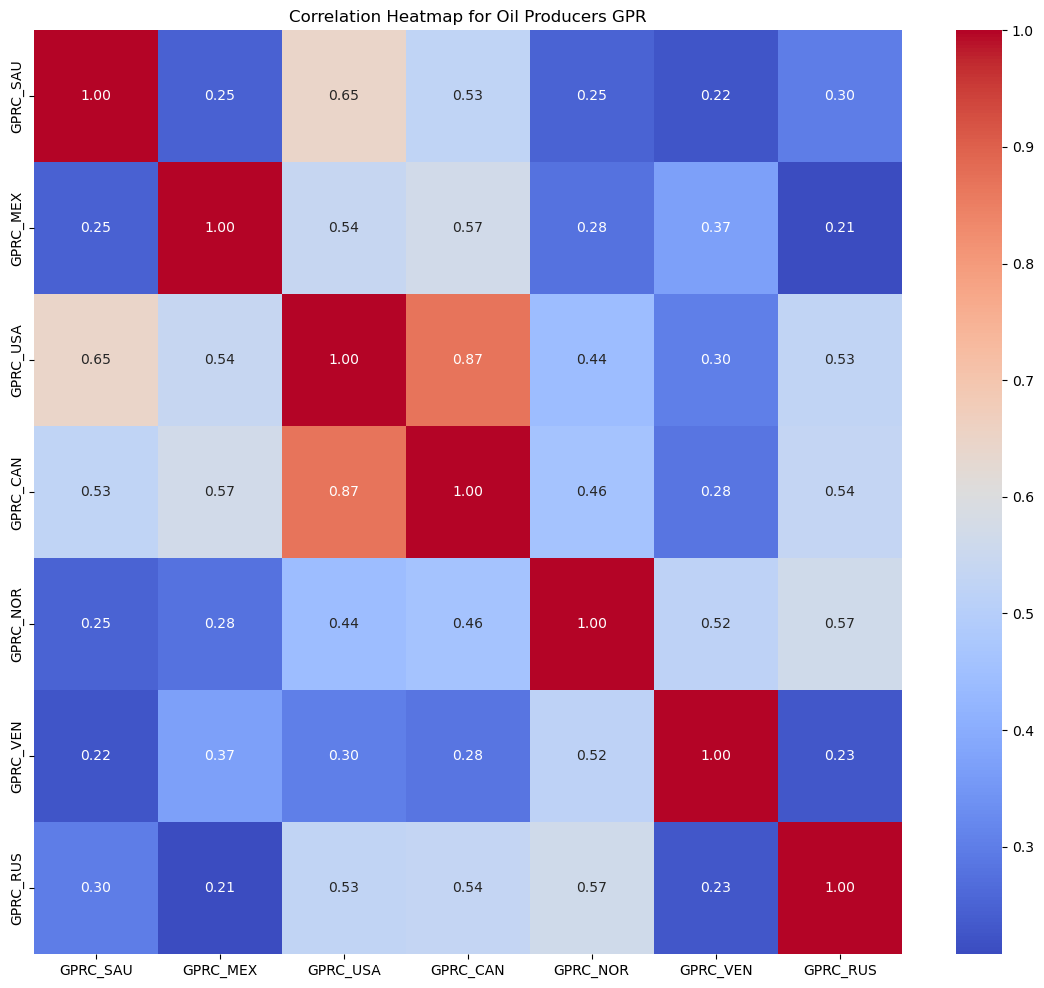

In [5]:
# --- Heatmap ---
corr_oil = df_oil.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr_oil, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for Oil Producers GPR')
plt.show()

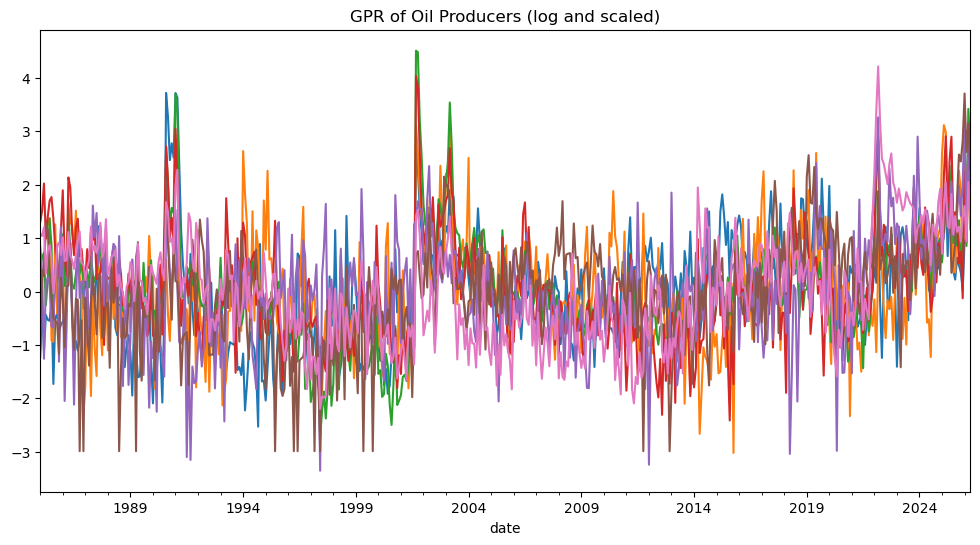

In [8]:
df_oil_scaled = prepare_group(df_oil)
df_oil_scaled.plot(subplots=False, figsize=(12, 6), legend=False,
                   title="GPR of Oil Producers (log and scaled)")
plt.show()

Explained variance by the first common factor (Oil): 0.5083552581202814


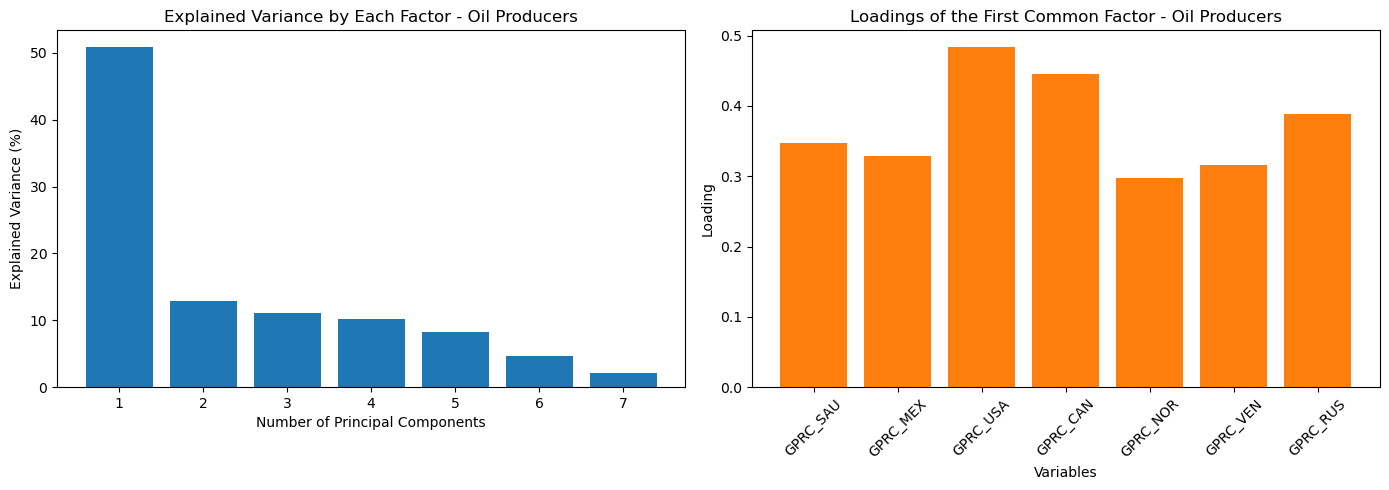

In [9]:
eigenval_oil, eigenvec_oil = np.linalg.eig(df_oil_scaled.cov())
idx_oil = np.argsort(eigenval_oil)[::-1]
eigenval_oil_s = eigenval_oil[idx_oil]
eigenvec_oil_s = eigenvec_oil[:, idx_oil]
cumsum_oil = np.cumsum(eigenval_oil_s) / np.sum(eigenval_oil_s)

print("Explained variance by the first common factor (Oil):", cumsum_oil[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(eigenval_oil_s) + 1),
            eigenval_oil_s / np.sum(eigenval_oil_s) * 100, color="tab:blue")
axes[0].set_xlabel("Number of Principal Components")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Explained Variance by Each Factor - Oil Producers")
axes[0].set_xticks(range(1, len(eigenval_oil_s) + 1))

first_loading_oil = eigenvec_oil_s[:, 0]
axes[1].bar(df_oil_scaled.columns, first_loading_oil, color="tab:orange")
axes[1].set_xlabel("Variables")
axes[1].set_ylabel("Loading")
axes[1].set_title("Loadings of the First Common Factor - Oil Producers")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

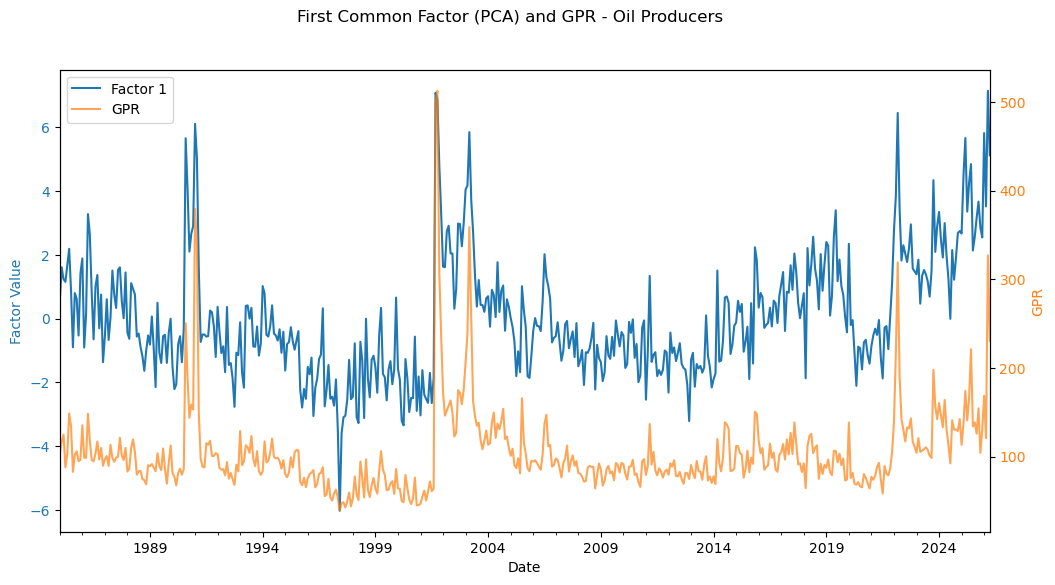

In [10]:
pca_oil = PCA(n_components=1)
factors_oil = pca_oil.fit_transform(df_oil_scaled)
factors_oil_df = pd.DataFrame(factors_oil, index=df_oil_scaled.index,
                               columns=["Factor_1_PCA"])
factors_oil_df = factors_oil_df.join(gpr["GPR"], how="left")

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
factors_oil_df["Factor_1_PCA"].plot(ax=ax1, color="tab:blue", label="Factor 1")
ax1.set_xlabel("Date")
ax1.set_ylabel("Factor Value", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
factors_oil_df["GPR"].plot(ax=ax2, color="tab:orange", label="GPR", alpha=0.7)
ax2.set_ylabel("GPR", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
fig.suptitle("First Common Factor (PCA) and GPR - Oil Producers")
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")
plt.show()

---
## South America Common Factor

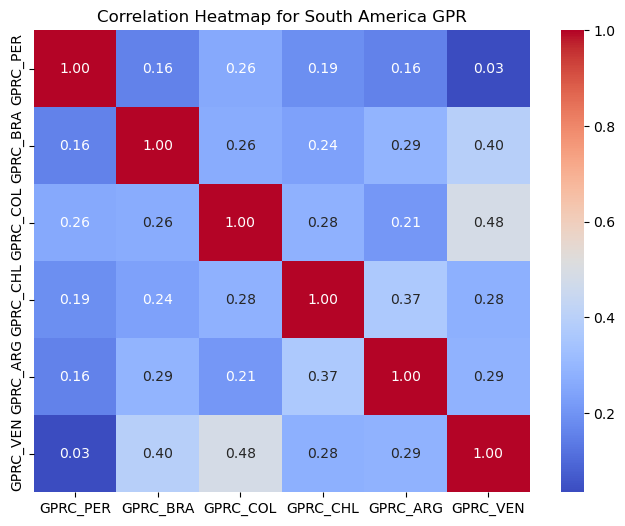

In [11]:
# --- Heatmap ---
corr_sa = df_sa.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_sa, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for South America GPR')
plt.show()

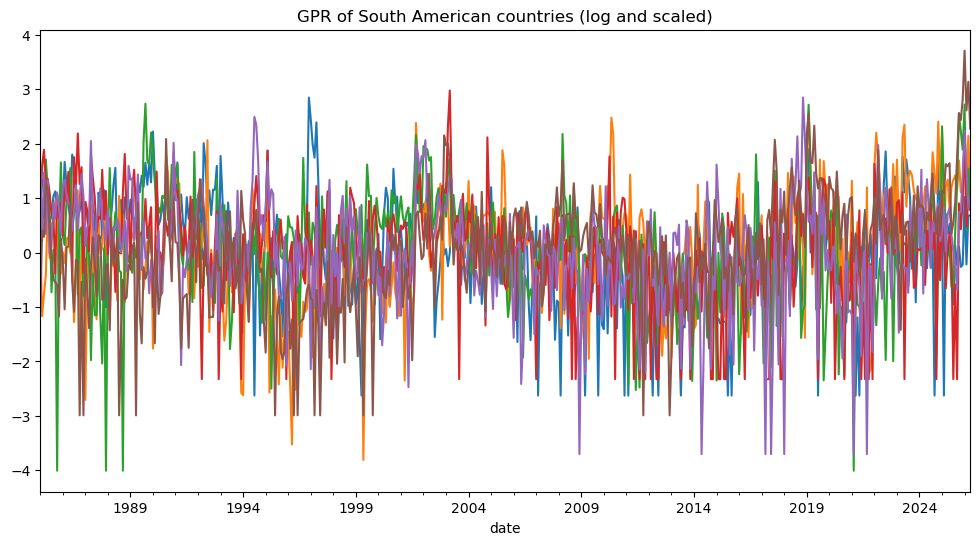

In [12]:
df_sa_scaled = prepare_group(df_sa)
df_sa_scaled.plot(subplots=False, figsize=(12, 6), legend=False,
                  title="GPR of South American countries (log and scaled)")
plt.show()

Explained variance by the first common factor (South America): 0.3828859796916122


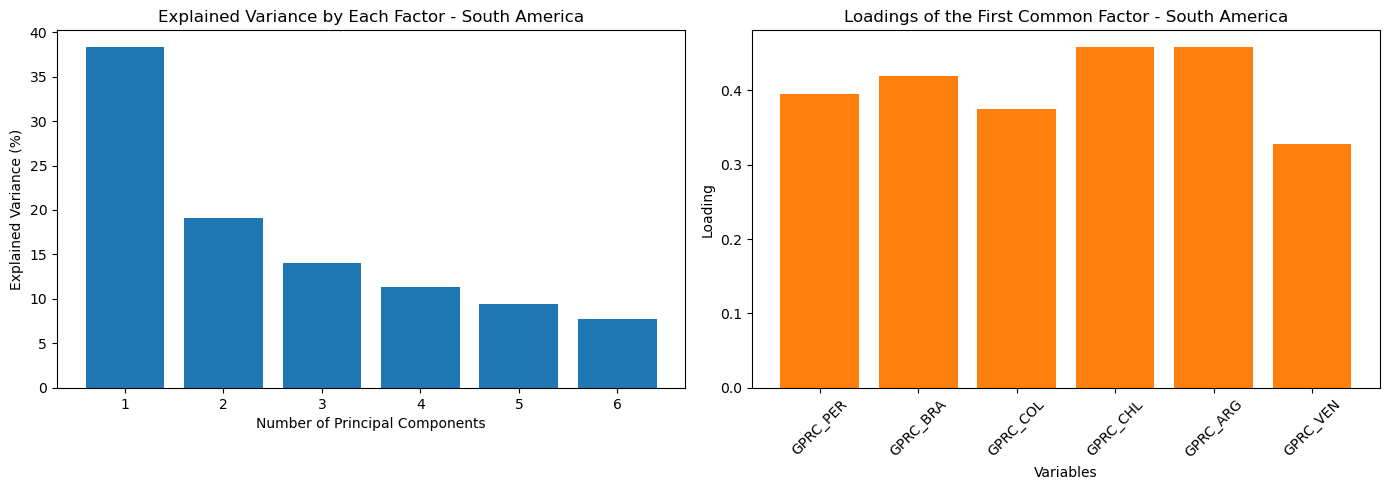

In [13]:
eigenval_sa, eigenvec_sa = np.linalg.eig(df_sa_scaled.cov())
idx_sa = np.argsort(eigenval_sa)[::-1]
eigenval_sa_s = eigenval_sa[idx_sa]
eigenvec_sa_s = eigenvec_sa[:, idx_sa]
cumsum_sa = np.cumsum(eigenval_sa_s) / np.sum(eigenval_sa_s)

print("Explained variance by the first common factor (South America):", cumsum_sa[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(eigenval_sa_s) + 1),
            eigenval_sa_s / np.sum(eigenval_sa_s) * 100, color="tab:blue")
axes[0].set_xlabel("Number of Principal Components")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Explained Variance by Each Factor - South America")
axes[0].set_xticks(range(1, len(eigenval_sa_s) + 1))

first_loading_sa = (-1) * eigenvec_sa_s[:, 0]
axes[1].bar(df_sa_scaled.columns, first_loading_sa, color="tab:orange")
axes[1].set_xlabel("Variables")
axes[1].set_ylabel("Loading")
axes[1].set_title("Loadings of the First Common Factor - South America")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

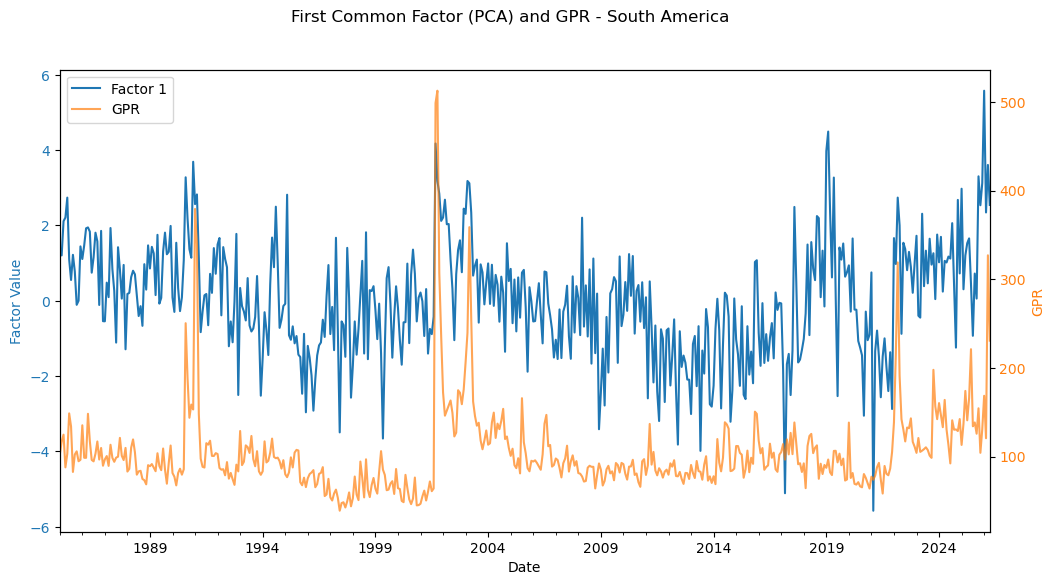

In [14]:
pca_sa = PCA(n_components=1)
factors_sa = pca_sa.fit_transform(df_sa_scaled)
factors_sa_df = pd.DataFrame(factors_sa, index=df_sa_scaled.index,
                              columns=["Factor_1_PCA"])
factors_sa_df = factors_sa_df.join(gpr["GPR"], how="left")

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
factors_sa_df["Factor_1_PCA"].plot(ax=ax1, color="tab:blue", label="Factor 1")
ax1.set_xlabel("Date")
ax1.set_ylabel("Factor Value", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
factors_sa_df["GPR"].plot(ax=ax2, color="tab:orange", label="GPR", alpha=0.7)
ax2.set_ylabel("GPR", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
fig.suptitle("First Common Factor (PCA) and GPR - South America")
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")
plt.show()

---
## BRICS Common Factor

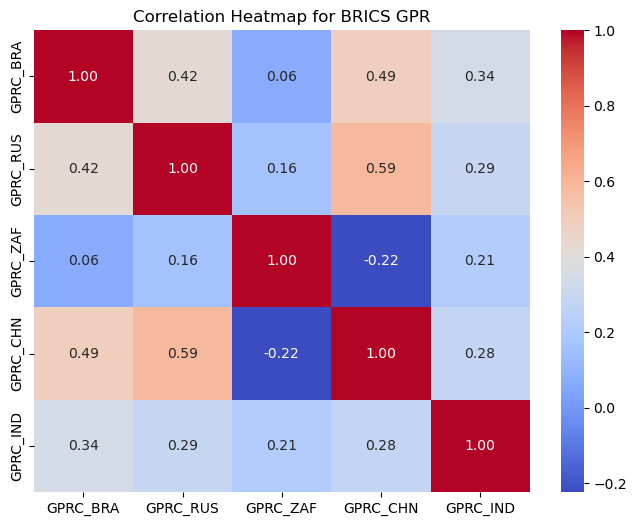

In [15]:
# --- Heatmap ---
corr_brics = df_brics.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_brics, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for BRICS GPR')
plt.show()

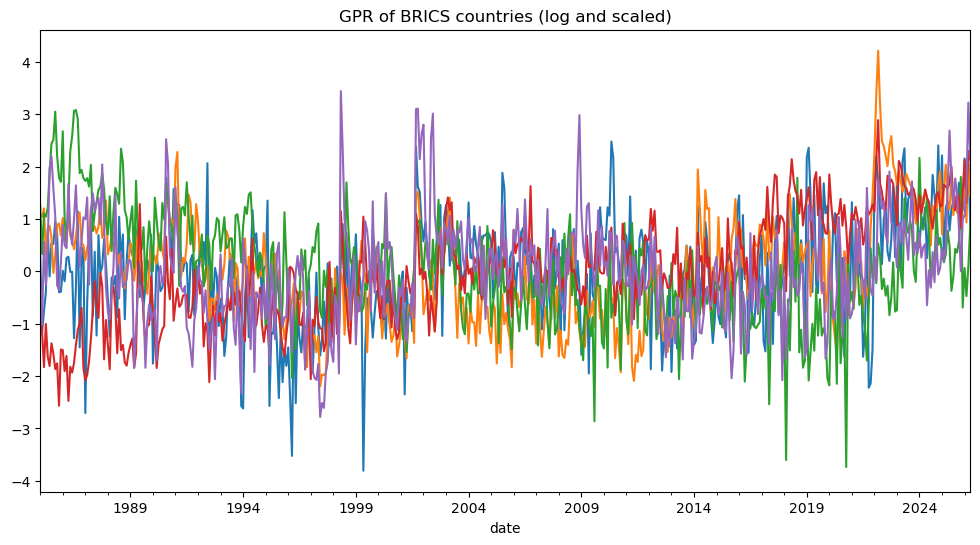

In [16]:
df_brics_scaled = prepare_group(df_brics)
df_brics_scaled.plot(subplots=False, figsize=(12, 6), legend=False,
                     title="GPR of BRICS countries (log and scaled)")
plt.show()

Explained variance by the first common factor (BRICS): 0.42880189792453466


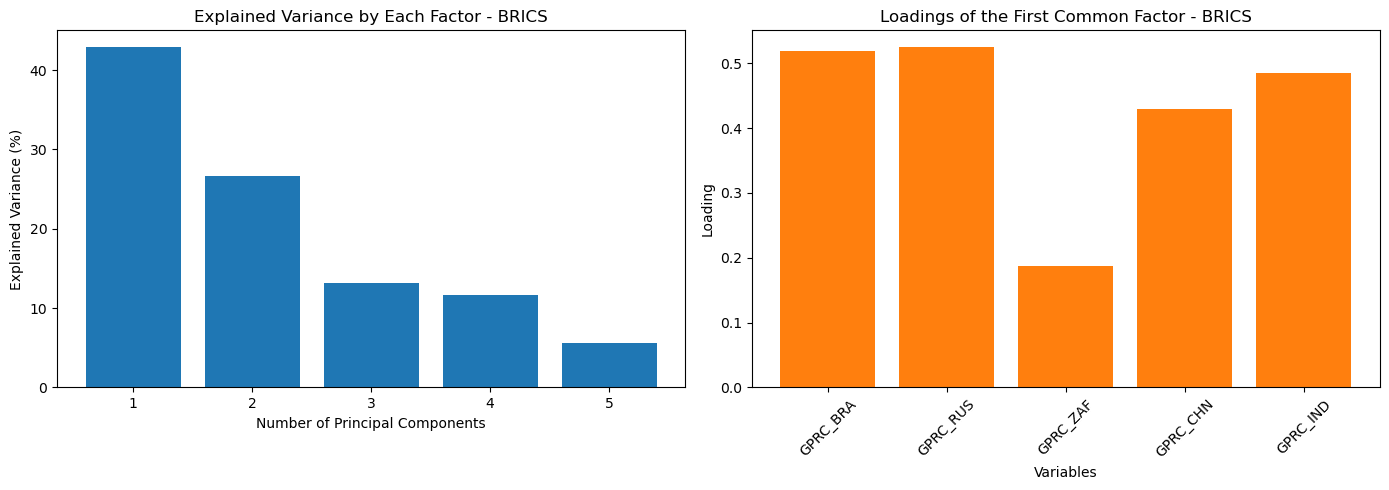

In [17]:
eigenval_brics, eigenvec_brics = np.linalg.eig(df_brics_scaled.cov())
idx_brics = np.argsort(eigenval_brics)[::-1]
eigenval_brics_s = eigenval_brics[idx_brics]
eigenvec_brics_s = eigenvec_brics[:, idx_brics]
cumsum_brics = np.cumsum(eigenval_brics_s) / np.sum(eigenval_brics_s)

print("Explained variance by the first common factor (BRICS):", cumsum_brics[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(eigenval_brics_s) + 1),
            eigenval_brics_s / np.sum(eigenval_brics_s) * 100, color="tab:blue")
axes[0].set_xlabel("Number of Principal Components")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Explained Variance by Each Factor - BRICS")
axes[0].set_xticks(range(1, len(eigenval_brics_s) + 1))

first_loading_brics = (-1) * eigenvec_brics_s[:, 0]
axes[1].bar(df_brics_scaled.columns, first_loading_brics, color="tab:orange")
axes[1].set_xlabel("Variables")
axes[1].set_ylabel("Loading")
axes[1].set_title("Loadings of the First Common Factor - BRICS")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

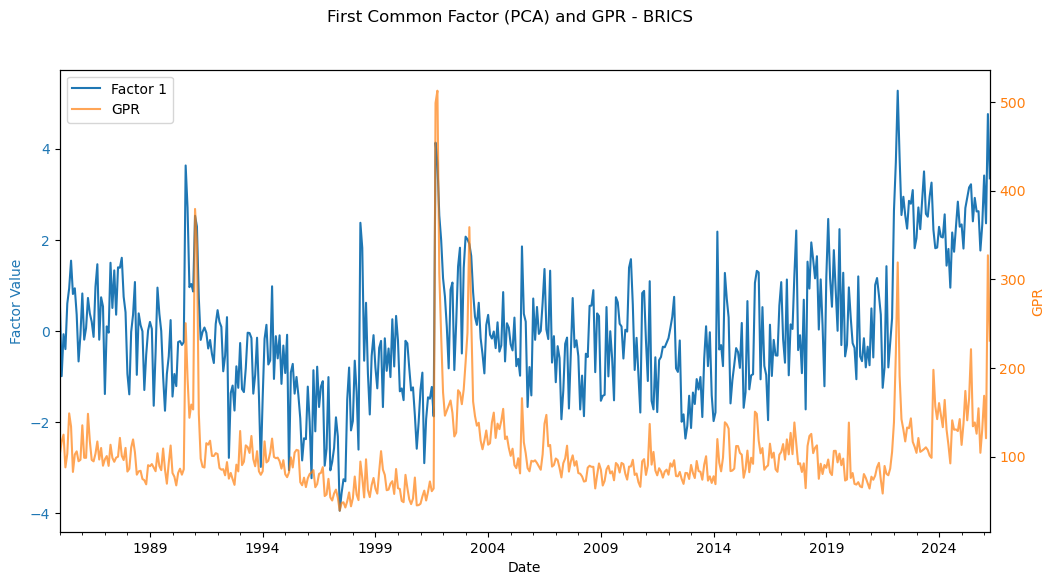

In [18]:
pca_brics = PCA(n_components=1)
factors_brics = pca_brics.fit_transform(df_brics_scaled)
factors_brics_df = pd.DataFrame(factors_brics, index=df_brics_scaled.index,
                                 columns=["Factor_1_PCA"])
factors_brics_df = factors_brics_df.join(gpr["GPR"], how="left")

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
factors_brics_df["Factor_1_PCA"].plot(ax=ax1, color="tab:blue", label="Factor 1")
ax1.set_xlabel("Date")
ax1.set_ylabel("Factor Value", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
factors_brics_df["GPR"].plot(ax=ax2, color="tab:orange", label="GPR", alpha=0.7)
ax2.set_ylabel("GPR", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
fig.suptitle("First Common Factor (PCA) and GPR - BRICS")
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")
plt.show()